### Let's open the data file and study the general information.

Historical data on game sales, user and expert ratings, genres, and platforms (such as Xbox or PlayStation) are available from open sources. It is necessary to identify the patterns that determine a game’s success. This will help focus on potentially popular products and plan advertising campaigns.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

data = pd.read_csv('/datasets/games.csv')
data

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Let's study the information about the data:

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### Prepare the data

We see that the column names contain both uppercase and lowercase letters. Let's convert everything to lowercase for convenience:

In [3]:
data.columns = data.columns.str.lower()
data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Let's check the lines for obvious duplicates:

In [4]:
data.duplicated().sum()

0

Let's check the data for missing values:

In [5]:
data.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

Let's look at the missing values as a percentage:

In [6]:
data.isnull().sum().sort_values(ascending = False) / data.shape[0] * 100

critic_score       51.319174
rating             40.478612
user_score         40.089740
year_of_release     1.609333
name                0.011965
genre               0.011965
platform            0.000000
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
dtype: float64

We see that there are two missing values ​​in the game title and genre columns. I think they should be removed, as without the game title, this data is useless. The gaps with the release year account for only 1.6% of the total—we can remove them as well.

In [7]:
data = data.dropna(subset=['name', 'genre', 'year_of_release'])

In [8]:
data.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         6605
rating             6676
dtype: int64

Let's check if the missing values in the remaining three columns somehow intersect:

In [9]:
data.query('critic_score.isnull() and user_score.isnull() and rating.isnull()').sort_values(by = 'name')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
14983,Beyblade Burst,3DS,2016.0,Role-Playing,0.00,0.00,0.03,0.00,NaN,NaN,NaN
1079,Fire Emblem Fates,3DS,2015.0,Role-Playing,0.81,0.23,0.52,0.11,NaN,NaN,NaN
3358,Frozen: Olaf's Quest,3DS,2013.0,Platform,0.27,0.27,0.00,0.05,NaN,NaN,NaN
3862,Frozen: Olaf's Quest,DS,2013.0,Platform,0.21,0.26,0.00,0.04,NaN,NaN,NaN
13794,Haikyu!! Cross Team Match!,3DS,2016.0,Adventure,0.00,0.00,0.04,0.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
12960,Zyuden Sentai Kyoryuger: Game de Gaburincho!!,3DS,2013.0,Action,0.00,0.00,0.05,0.00,NaN,NaN,NaN
16389,ef - a fairy tale of the two.,PS2,2010.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
12190,everGirl,GBA,2005.0,Adventure,0.05,0.02,0.00,0.00,NaN,NaN,NaN
16511,th!nk Logic Trainer,Wii,2009.0,Puzzle,0.01,0.00,0.00,0.00,NaN,NaN,NaN


We see that there is no general sign of absence of values in these columns.

The remaining three columns have too many missing values. If we change them, the statistics will be skewed. Let's check how many unique values are in each:

In [10]:
data['critic_score'].value_counts()

70.0    252
71.0    248
75.0    240
80.0    235
73.0    234
       ... 
29.0      3
20.0      3
13.0      1
17.0      1
21.0      1
Name: critic_score, Length: 81, dtype: int64

In [11]:
data.query('critic_score.isnull()')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [12]:
data['user_score'].value_counts()

tbd    2376
7.8     322
8       285
8.2     276
8.3     252
       ... 
1.9       2
2.3       2
1.1       2
9.7       1
0         1
Name: user_score, Length: 96, dtype: int64

The largest number is for the strange tbd value, which isn't a number, as it should be in this column. Google told us that this value—"To be determined"—is subject to determination. It's used in cases where development is being done by multiple people/teams, and one branch hasn't yet been finalized. This means we definitely can't delete this value, nor can we replace it with '0', because '0' could be a real score. We need to replace it with a value that we know will never occur, to ensure it's not real or temporary. For example, -5. We'll do the same for the missing values in the user_score and critic_score columns:

In [13]:
pd.options.mode.chained_assignment = None

In [52]:
data['user_score'] = data['user_score'].replace('tbd', '-5') #when the real values are loaded, tbd will no longer be encountered
data['user_score'] = data['user_score'].fillna(-5) #after loading tbd, -5 will remain only in values ​​that are missing for other reasons
data['critic_score'] = data['critic_score'].fillna(-5)
data.isna().sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
sales_total        0
dtype: int64

In [15]:
data['rating'].value_counts()

E       3921
T       2905
M       1536
E10+    1393
EC         8
K-A        3
RP         1
AO         1
Name: rating, dtype: int64

The values in the rating column are text, in the 'object' format, so replacing missing values ​​with numbers would be incorrect. Let's replace them with the value 'unknown'.

In [16]:
data['rating'] = data['rating'].fillna('unknown')
data.isna().sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

Now we can change the data type:

In [17]:
data['year_of_release'] = data['year_of_release'].astype('Int64')
data['user_score'] = data['user_score'].astype('float64')
data['critic_score'] = data['critic_score'].astype('Int64')
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     16444 non-null  Int64  
 9   user_score       16444 non-null  float64
 10  rating           16444 non-null  object 
dtypes: Int64(2), float64(5), object(4)
memory usage: 1.5+ MB


Let's calculate the total sales in all regions and write them down in a separate column:

In [18]:
data['sales_total'] = data.loc[:, ['na_sales', 'eu_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,111.50
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-5,-5.0,unknown,43.82
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,48.28
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,43.70
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-5,-5.0,unknown,40.27
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,-5,-5.0,unknown,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,-5,-5.0,unknown,0.02
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,-5,-5.0,unknown,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,-5,-5.0,unknown,0.01


### Conduct exploratory data analysis

#### Look at how many games were released in different years. Is data for all periods important?

Let's build a summary table by year of release and sum up the number of games released in each year and, for clarity, immediately build a graph:

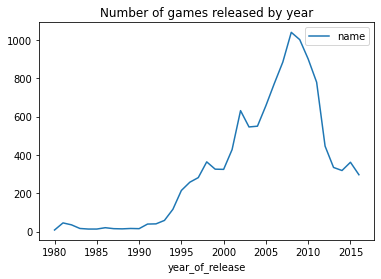

In [19]:
games_per_year = (
    data[['name', 'year_of_release']]
        .drop_duplicates()
        .pivot_table(index='year_of_release', values='name', aggfunc='count')
        .sort_values('year_of_release', ascending=False)
        .plot(title = 'Number of games released by year')
)

The graph shows that the gaming industry's heyday occurred between 2005 and 2010. Before 1994, few games were released, and I think this period is less important for analysis because many modern technologies simply didn't exist back then, and the industry as a whole didn't exist in its current form.

#### See how sales have changed across platforms.

Let's select the platforms with the highest total sales and plot a distribution by year. What's the typical time frame for new platforms to emerge and old ones to disappear?

First, let's select platforms based on total sales:

In [20]:
sales_total_per_platform = (data.groupby(['platform'], as_index = False)['sales_total'].sum()
                                .sort_values('sales_total', ascending = False))
sales_total_per_platform

,platform,sales_total
16,PS2,1566.19
17,PS3,1258.55
28,X360,1229.56
26,Wii,1149.50
4,DS,991.19
15,PS,939.97
18,PS4,455.23
13,PC,396.13
6,GBA,387.47
19,PSP,355.15


For clarity, let's plot a graph based on this data:

<AxesSubplot:title={'center':'Sales by platform'}, xlabel='platform'>

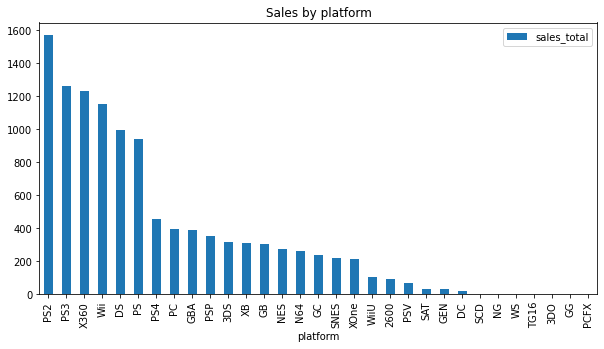

In [42]:
sales_total_per_platform.plot(kind='bar', x='platform', y='sales_total', figsize = (10, 5), title = 'Sales by platform')

The graph shows that the PS2 and PS3 have the highest sales figures. Let's select the first six clear peaks for analysis: PS2, PS3, X360, Wii, DS, PS.

In [22]:
top_6_per_years = sales_total_per_platform.head(6)['platform'].tolist()
#top_6_per_years = sales_total_per_platform.sort_values(by=['platform'].head(5))
top_6_per_years

['PS2', 'PS3', 'X360', 'Wii', 'DS', 'PS']

Now let's build a summary and a graph by year for each game from our TOP-6:

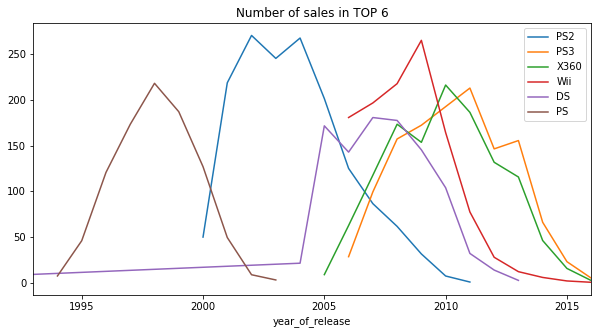

In [43]:
for index in top_6_per_years:
    (data.query('platform == @index and year_of_release != -5')
         .pivot_table(index = 'year_of_release', values = 'sales_total', aggfunc = 'sum')
         .sort_values('year_of_release', ascending = False)['sales_total']
         .plot(figsize = (10, 5), label = index, legend = True, title = 'Number of sales in TOP 6', xlim = (1993, 2016))
    )

The graph shows that the original PS4 was released in 1994 and gained popularity around 1999. The second version was released five years later and was also popular for about five years. The same can be said for the Wii and DS. From this, we can conclude that the relevant period for us is the last five years, during which new platforms were released or those that are still popular. In other words, this data is from 2012.

<AxesSubplot:title={'center':'Number of sales by platform since 2012'}, xlabel='platform'>

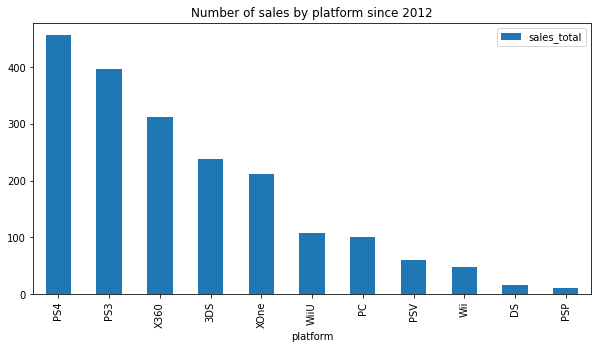

In [44]:
platforms_actual = data.query('year_of_release >= 2012')
platforms_actual_top = (platforms_actual
                         .groupby(['platform'],as_index = False)['sales_total']
                         .sum()
                         .sort_values('sales_total', ascending = False)
                           )
platforms_actual_top.plot(kind = 'bar', x = 'platform', y = 'sales_total',figsize = (10, 5), title = 'Number of sales by platform since 2012')

We've identified the top sellers for the current period. Now let's look at how sales are changing year-over-year.

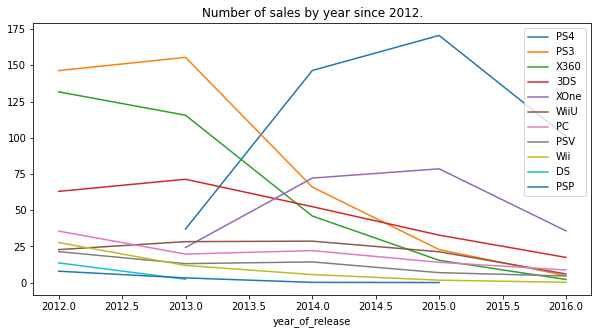

In [45]:
platforms_lead = platforms_actual_top['platform'].tolist()
for index in platforms_lead:
    (platforms_actual.query('platform == @index')
                     .pivot_table(index = 'year_of_release', values = 'sales_total', aggfunc = 'sum')
                     .sort_values('year_of_release', ascending = False)['sales_total']
                     .plot(figsize=(10, 5), label = index, legend = True, title = 'Number of sales by year since 2012.')
    )

The graph shows that sales are declining for all platforms. The market leaders—PS4 and X-One—started declining later than the others, in 2015. However, we keep in mind that the 2016 data may be incomplete, so it's likely that growth will also occur after the data is updated. We can consider them potentially profitable.

In [26]:
platforms_actual

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97,8.2,M,30.14
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97,8.1,M,21.41
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,-5,-5.0,unknown,20.49
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,-5,-5.0,unknown,18.79
34,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83,5.3,M,19.52
...,...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,-5,-5.0,unknown,0.01
16707,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,-5,-5.0,unknown,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,-5,-5.0,unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,-5,-5.0,unknown,0.01


In [27]:
platforms_potential = platforms_actual.query('platform == "PS4" or platform == "XOne"')
platforms_potential_group = (platforms_potential
                       .groupby(['platform', 'year_of_release'], as_index = False)['sales_total'].sum()
                       .sort_values('platform', ascending = False)
                           )
platforms_potential_group

,platform,year_of_release,sales_total
4,XOne,2013,24.30
5,XOne,2014,72.22
6,XOne,2015,78.61
7,XOne,2016,35.78
0,PS4,2013,37.04
1,PS4,2014,146.50
2,PS4,2015,170.66
3,PS4,2016,101.03


**Create a box plot of global game sales by platform.**

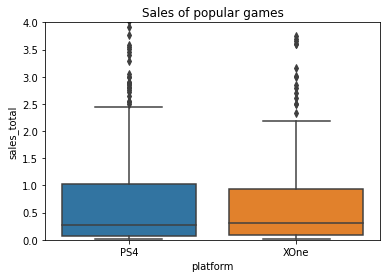

In [46]:
ax = sns.boxplot(x = 'platform', y = 'sales_total', data = platforms_potential)
ax.set(ylim = (0, 4), title = 'Sales of popular games');

From the graph, we see that both platforms average around 1 million copies sold. For more precise figures, look at the table:

In [29]:
platforms_potential.query('platform == "PS4"').describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,sales_total
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,2015.145408,0.277398,0.359923,0.040714,0.123342,44.558673,2.702296,1.161301
std,0.868181,0.583723,0.810843,0.069101,0.254825,38.315111,5.712921,2.397631
min,2013.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,-5.000000,0.010000
25%,2015.000000,0.007500,0.000000,0.000000,0.010000,-5.000000,-5.000000,0.070000
50%,2015.000000,0.060000,0.080000,0.010000,0.030000,64.500000,6.100000,0.280000
75%,2016.000000,0.260000,0.300000,0.050000,0.110000,77.000000,7.500000,1.022500
max,2016.000000,6.030000,6.310000,0.490000,2.380000,97.000000,9.200000,20.490000


In [30]:
platforms_potential.query('platform == "XOne"').describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,sales_total
count,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000
mean,2014.951417,0.377004,0.208866,0.001377,0.057773,48.591093,3.489474,0.853887
std,0.952995,0.630618,0.365306,0.005153,0.094221,38.019983,5.219909,1.373632
min,2013.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,-5.000000,0.010000
25%,2014.000000,0.030000,0.020000,0.000000,0.010000,-5.000000,-5.000000,0.080000
50%,2015.000000,0.120000,0.070000,0.000000,0.020000,67.000000,6.000000,0.300000
75%,2016.000000,0.385000,0.220000,0.000000,0.060000,79.000000,7.200000,0.935000
max,2016.000000,4.590000,2.190000,0.040000,0.680000,97.000000,9.200000,9.500000


The PS4 has an average of 1.37 million copies sold, while the X-One has 0.85 million. However, the PS4's peak sales are almost twice as high. This outlier may be due to a specific top-tier game. These peaks can significantly distort our average, but if we look at the median, it's almost identical for both platforms, and even lower for the PS4 (0.28 million) than for the X-One (0.3 million).

**Let's look at how user and critic reviews influence sales within a popular platform. Create a scatterplot and calculate the correlation between reviews and sales.**

To see the relationship, we need to look at the correlation coefficient. To do this, we'll first split our platforms into two separate slices:

In [31]:
ps4 = platforms_potential.query('platform == "PS4" and user_score != -5 and critic_score != -5 and sales_total != -5')      
xone = platforms_potential.query('platform == "XOne" and user_score != -5 and critic_score != -5 and sales_total != -5')

I added conditions to the cell above to cut off our '-5' marks.

Let's explore PS4:

In [32]:
feedback = ['user_score', 'critic_score', 'sales_total']
ps4[feedback].corr()

,user_score,critic_score,sales_total
user_score,1.000000,0.557654,-0.040030
critic_score,0.557654,1.000000,0.389265
sales_total,-0.040030,0.389265,1.000000


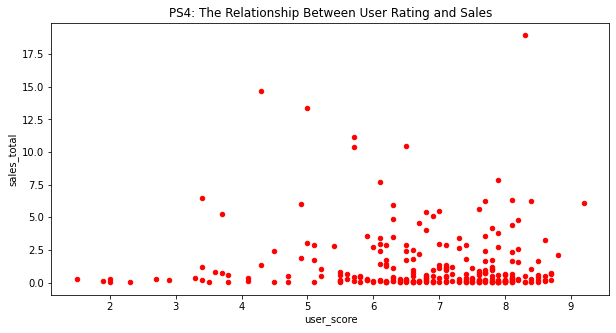

In [47]:
(ps4
     .plot(kind='scatter', x='user_score', y='sales_total', 
     title='PS4: The Relationship Between User Rating and Sales', figsize = (10, 5), color = 'red')
);

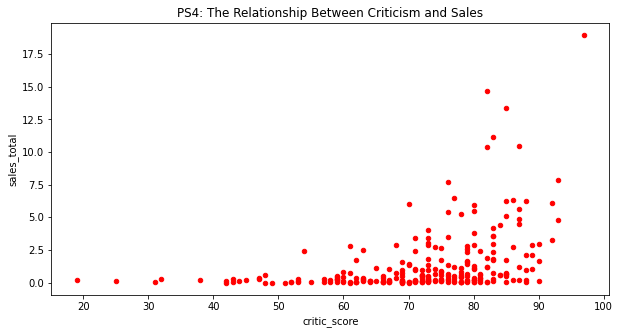

In [48]:
(ps4
     .plot(x = 'critic_score', y = 'sales_total', 
           kind='scatter', title='PS4: The Relationship Between Criticism and Sales', 
           figsize = (10, 5), color = 'red')
);

Let's study XOne:

In [35]:
xone[feedback].corr()

,user_score,critic_score,sales_total
user_score,1.000000,0.472462,-0.091516
critic_score,0.472462,1.000000,0.411427
sales_total,-0.091516,0.411427,1.000000


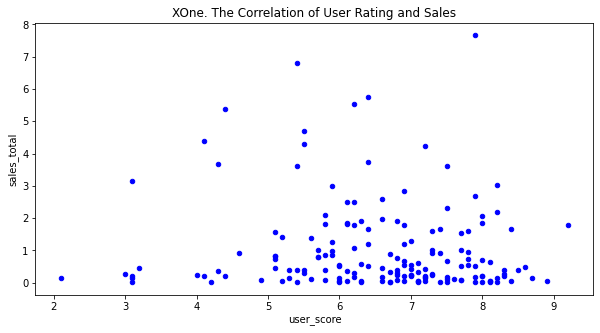

In [49]:
(xone
    .plot(x = 'user_score', y = 'sales_total', 
          kind='scatter', title='XOne. The Correlation of User Rating and Sales', 
          figsize = (10, 5), color = 'blue')
);

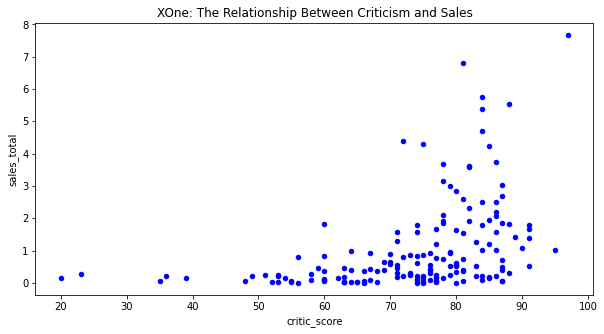

In [50]:
(xone
    .plot(x = 'critic_score', y = 'sales_total', 
    kind='scatter', title='XOne: The Relationship Between Criticism and Sales', 
    figsize = (10, 5), color = 'blue')
);

For both platforms, we see that the Pearson coefficients are closer to 0 than to 1, suggesting that user and critic reviews have almost no impact on sales. This may be due to users' prior experience, which allows them to trust the platform and purchase new products. This means that users will rely more on their own experience and impressions than on reviews. Looking at the graphs, we see that sales are correlated with critic reviews, but it's not clear that this correlation is linear. However, we do see agreement between user and critic reviews—their correlation coefficient is almost 1.

**Let's look at the general distribution of games by genre.**

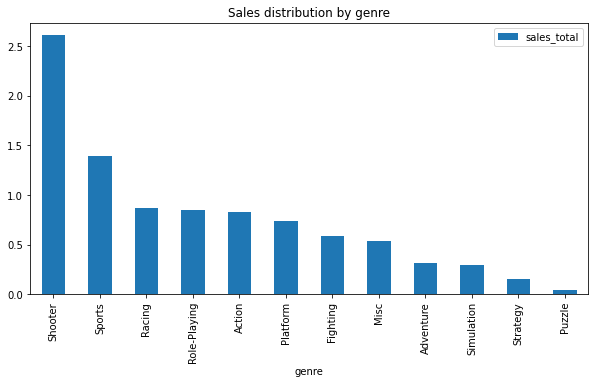

In [51]:
(platforms_potential
    .pivot_table(index = 'genre', values = 'sales_total')
    .sort_values('sales_total', ascending = False)
    .plot(kind='bar', y='sales_total', figsize=(10, 5), title = 'Sales distribution by genre')
    );

The graph shows that shooters lead sales by a wide margin. I'd also include sports games among the most profitable, along with racing, role-playing games, and action games, with nearly equal sales. Puzzles have the fewest sales. It would be odd to buy an expensive gaming console just to solve puzzles; you can often solve them for free, and they're likely just for children's educational content. That is, puzzles are played by older children who play shooters. :)

### Let's create a user profile for each region

In [39]:
regions = ['na_sales','eu_sales','jp_sales']

**The most popular platforms (top 5)**

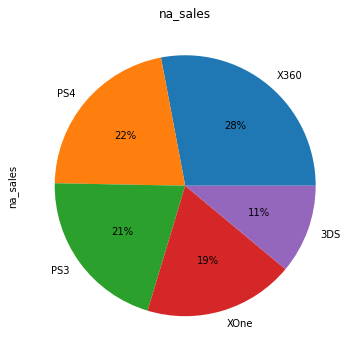

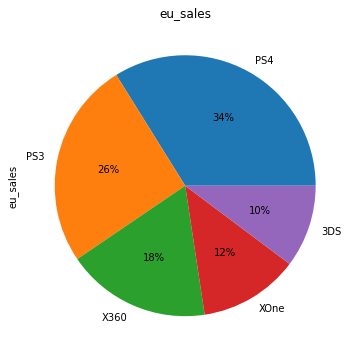

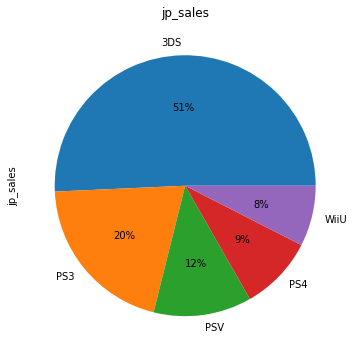

In [40]:
#fig, ((ax0, ax1, ax2)) = plt.subplots(nrows=1, ncols=3)

for index in regions:
    (platforms_actual.
     pivot_table(index = 'platform', values = index, aggfunc='sum')
     .sort_values(index, ascending=False).head(5)
     .plot(kind='pie', autopct='%1.0f%%', y = index, figsize=(6, 6), legend = False, title = index)
    )

In North America, the most popular platform is the X360,

In Europe, it's the PS4,

And in Japan, the 3DS is far ahead, with the PS4 being completely unpopular there (in terms of the top 5).

Furthermore, the WiiU and PS4, which weren't in the European or American sample, have made it into the top 5 in Japan. A quick Google search reveals that the 3DS and WiiU are Nintendo products, manufactured in Japan. True, PlayStations are also Japanese, but for some reason haven't caught on in their home country. Some speculate that Nintendo can survive on the strength of various portable devices, which is more relevant in Japan, but perhaps not.

From all of the above, we can conclude that the most patriotic users are Americans and Japanese, and it's time for Europeans (including us) to come up with something of their own.

**Most popular genres (top 5)**

In [ ]:
for index in regions:
    (platforms_actual
         .pivot_table(index = 'genre', values = index, aggfunc='sum')
         .sort_values(index, ascending=False).head(5)
         .plot(kind='pie', autopct='%1.0f%%', y = index, figsize=(6, 6), legend = False, title = index)
    )

North Americans love shooters and action games, and not just in games. Europe is a bit more peaceful, but we're still a long way from the Japanese.

**Does the ESRB rating affect sales in a particular region?**

In [ ]:
for index in regions:
    (platforms_actual
         .pivot_table(index = 'rating', values = index, aggfunc='sum')
         .sort_values(index, ascending=False).head(5)
         .plot(kind='pie', autopct='%1.0f%%', y = index, figsize=(6, 6), legend = False, title = index)
    )

We see that the ESRB isn't very fond of Japan. And indeed:

_"A non-governmental organization whose primary activity is the adoption and determination of ratings for computer video games and other entertainment software in the United States and Canada." (c)_

Nevertheless, it managed to assign ratings to games that (apparently) were released simultaneously in the American and European continents and in Japan. The very Japanese feel correlates with the popularity of platforms in this mysterious country.

The following user profiles emerge from the graphs provided:
- In North America, mostly people in the M (17+) and E (everyone) categories play shooters and action games, primarily on Microsoft's Xbox.
- In Europe, the same people play the same games, only on PlayStation.
- In Japan, some strange people play role-playing games on something else entirely:) Oh, those Japanese!

### Let's test the hypotheses

The `st.ttest_ind` method is suitable for us to test hypotheses, because for comparison we take two independent samples and compare their mean.

H0: Average user ratings for the Xbox One and PC platforms are the same.

H1: Average user ratings for the Xbox One and PC platforms are different.

Let's select two samples for comparison:

In [54]:
xbox = platforms_actual.query('platform == "XOne" and user_score != -5')
pc = platforms_actual.query('platform == "PC" and user_score != -5')

print("Sample variance Xbox One", np.var(xbox['user_score']))
print("Sample variance PC", np.var(pc['user_score']))

Sample variance Xbox One 1.8965188383045526
Sample variance PC 2.7569952398906588


In [55]:
alpha = 0.05

results = st.ttest_ind(
    xbox['user_score'],
    pc['user_score'],
    equal_var=False 
)

print('p-value:', results.pvalue)

if (results.pvalue < alpha):
    print("We reject the null hypothesis")
else:
    print("The null hypothesis could not be rejected")

p-value: 0.5489537965134912
The null hypothesis could not be rejected


The p-value tells us that there's a roughly 55% chance that the difference in ratings on these two platforms could be due to chance. This marginal figure can be interpreted to mean that a difference of almost the same percentage might not be due to chance. Since there's no certainty, we don't reject the null hypothesis and instead test it in a human-like manner:

In [ ]:
xbox['user_score'].mean()

In [ ]:
pc['user_score'].mean()

The same small difference as in the hypotheses. As the theory dictated, if you can't prove otherwise, then stick with the null hypothesis, so we assume the average user ratings on these two platforms are the same.

Hypothesis Test:

**Average user ratings for the Action and Sports genres differ.**

H0: Average user ratings for the Action and Sports genres are the same.

H1: Average user ratings for the Action and Sports genres are different.

In [56]:
action = platforms_actual.query('genre == "Action" and user_score != -5')
sport = platforms_actual.query('genre == "Sports" and user_score != -5')

print("Sample variance action",np.var(action['user_score']))
print("Sample variance sport",np.var(sport['user_score']))

Sample variance action 1.8854720340439224
Sample variance sport 3.0073882971729127


In [57]:
alpha = 0.05

results = st.ttest_ind(
    action['user_score'],
    sport['user_score'],
    equal_var=False,
)

print('p-value:', results.pvalue)

if (results.pvalue < alpha):
    print("We reject the null hypothesis")
else:
    print("The null hypothesis could not be rejected")

p-value: 4.24307776572644e-20
We reject the null hypothesis


The p-value tells us that the difference between the observed and expected values ​​is large enough that the probability of obtaining it by chance is very low. Let's check:

In [ ]:
action['user_score'].mean()

In [ ]:
sport['user_score'].mean()

There is indeed a difference in ratings, so we reject the null hypothesis and confirm our hypothesis that the average user ratings of the Action and Sports genres are different.

###  General conclusion

To plan advertising campaigns and study the market, it's necessary to determine the target audience. For example, if the ad is for North American users, it's best to offer them shooters and action games on Xbox, and target the ads by age category (this requires more fine-grained settings for each specific game).

For Europe, it's best to plan ads for shooters and action games on PS, with the same fine-grained age category settings for each specific game card. If we have a lot of money, we can also target puzzles so they're shown to people who were previously interested in them.

For Japan, the market needs to be studied in more detail using additional sources. For example, where exactly will this advertising take place—most likely on alternative services that are more popular in Asia. The specifics of these services should be studied. I think the list of game titles that will be of interest to the Japanese audience also needs to be studied in more detail, rather than just focusing on genres. The audience there is large, so we wouldn't want to miss out on this market, but we need to thoroughly study its specifics. Blank data points could result in a failed advertising campaign. However, based on the data we have, we can confidently say that RPGs and action games released for Nintendo platforms are the best choices for Japan.